In [4]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [8]:
ticker_symbol = "SPY"
ticker = yf.Ticker(ticker_symbol)


In [15]:
history = ticker.history(period="5d")

spot_price = history["Close"].iloc[-1]

print("Current SPY price:", spot_price)
print(pd.DataFrame(history))

Current SPY price: 756.3099975585938
                                 Open        High         Low       Close  \
Date                                                                        
2026-06-09 00:00:00-04:00  743.630005  746.900024  722.590027  737.049988   
2026-06-10 00:00:00-04:00  733.390015  738.380005  725.330017  725.429993   
2026-06-11 00:00:00-04:00  728.760010  740.000000  724.409973  737.760010   
2026-06-12 00:00:00-04:00  740.710022  744.440002  735.030029  741.750000   
2026-06-15 00:00:00-04:00  751.849976  756.669983  751.760010  756.309998   

                             Volume  Dividends  Stock Splits  Capital Gains  
Date                                                                         
2026-06-09 00:00:00-04:00  87683500        0.0           0.0            0.0  
2026-06-10 00:00:00-04:00  60341300        0.0           0.0            0.0  
2026-06-11 00:00:00-04:00  86330500        0.0           0.0            0.0  
2026-06-12 00:00:00-04:00  569398

In [16]:
expirations = ticker.options

print(expirations)

('2026-06-15', '2026-06-16', '2026-06-17', '2026-06-18', '2026-06-22', '2026-06-23', '2026-06-24', '2026-06-25', '2026-06-26', '2026-06-30', '2026-07-02', '2026-07-10', '2026-07-17', '2026-07-24', '2026-07-31', '2026-08-21', '2026-08-31', '2026-09-18', '2026-09-30', '2026-10-16', '2026-10-30', '2026-11-20', '2026-11-30', '2026-12-18', '2026-12-31', '2027-01-15', '2027-03-19', '2027-03-31', '2027-06-17', '2027-09-17', '2027-12-17', '2028-01-21', '2028-06-16', '2028-12-15')


In [22]:
expiration = expirations[12]

print("Selected expiration:", expiration)

Selected expiration: 2026-07-17


In [28]:
option_chain = ticker.option_chain(expiration)

calls = option_chain.calls

puts = option_chain.puts

calls.head()

,contractSymbol,lastTradeDate,strike,lastPrice,bid,ask,change,percentChange,volume,openInterest,impliedVolatility,inTheMoney,contractSize,currency
0,SPY260717C00360000,2026-06-05 15:45:22+00:00,360.0,387.81,394.60,397.42,0.0,0.0,1.0,50,1.161869,True,REGULAR,USD
1,SPY260717C00365000,2026-05-28 14:12:58+00:00,365.0,388.54,389.65,392.47,0.0,0.0,1.0,31,1.149662,True,REGULAR,USD
2,SPY260717C00370000,2026-05-01 16:21:26+00:00,370.0,355.11,368.15,370.93,0.0,0.0,10.0,1,0.000010,True,REGULAR,USD
3,SPY260717C00375000,2026-05-06 15:33:13+00:00,375.0,358.95,363.16,365.94,0.0,0.0,13.0,5,0.000010,True,REGULAR,USD
4,SPY260717C00380000,2026-05-21 15:07:20+00:00,380.0,358.86,374.30,377.56,0.0,0.0,NaN,10,1.104253,True,REGULAR,USD


In [30]:
calls = calls[
   [
       "strike",
        "bid",
        "ask",
        "lastPrice",
        "volume",
        "openInterest",
        "impliedVolatility"
    ]

].copy()

calls.head()

,strike,bid,ask,lastPrice,volume,openInterest,impliedVolatility
0,360.0,394.60,397.42,387.81,1.0,50,1.161869
1,365.0,389.65,392.47,388.54,1.0,31,1.149662
2,370.0,368.15,370.93,355.11,10.0,1,0.000010
3,375.0,363.16,365.94,358.95,13.0,5,0.000010
4,380.0,374.30,377.56,358.86,NaN,10,1.104253


In [32]:
calls["mid_price"] = (calls["bid"] + calls["ask"]) / 2
calls[["strike", "bid", "ask", "mid_price"]].head(10)

,strike,bid,ask,mid_price
0,360.0,394.60,397.42,396.010
1,365.0,389.65,392.47,391.060
2,370.0,368.15,370.93,369.540
3,375.0,363.16,365.94,364.550
4,380.0,374.30,377.56,375.930
5,385.0,369.23,372.56,370.895
6,395.0,359.31,362.57,360.940
7,400.0,354.52,357.35,355.935
8,405.0,349.31,352.51,350.910
9,410.0,328.09,330.90,329.495


In [37]:
calls = calls[ (calls["bid"] > 0) & (calls["ask"] > calls["bid"])].copy()

calls["relative_spread"] = (calls["ask"] - calls["bid"]) / calls["mid_price"]

calls = calls[calls["relative_spread"] < 0.30].copy()

calls = calls[calls["openInterest"] > 0].copy()

calls.head()

,strike,bid,ask,lastPrice,volume,openInterest,impliedVolatility,mid_price,relative_spread
0,360.0,394.60,397.42,387.81,1.0,50,1.161869,396.01,0.007121
1,365.0,389.65,392.47,388.54,1.0,31,1.149662,391.06,0.007211
2,370.0,368.15,370.93,355.11,10.0,1,0.000010,369.54,0.007523
3,375.0,363.16,365.94,358.95,13.0,5,0.000010,364.55,0.007626
4,380.0,374.30,377.56,358.86,NaN,10,1.104253,375.93,0.008672


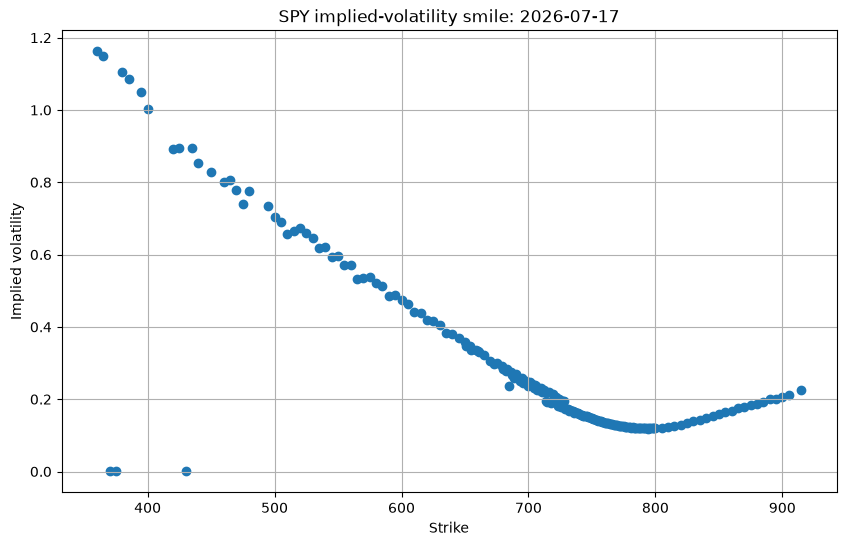

In [38]:
plt.figure(figsize=(10, 6))

plt.scatter(
    calls["strike"],
    calls["impliedVolatility"]
)

plt.xlabel("Strike")
plt.ylabel("Implied volatility")
plt.title(f"SPY implied-volatility smile: {expiration}")
plt.grid()

plt.show()

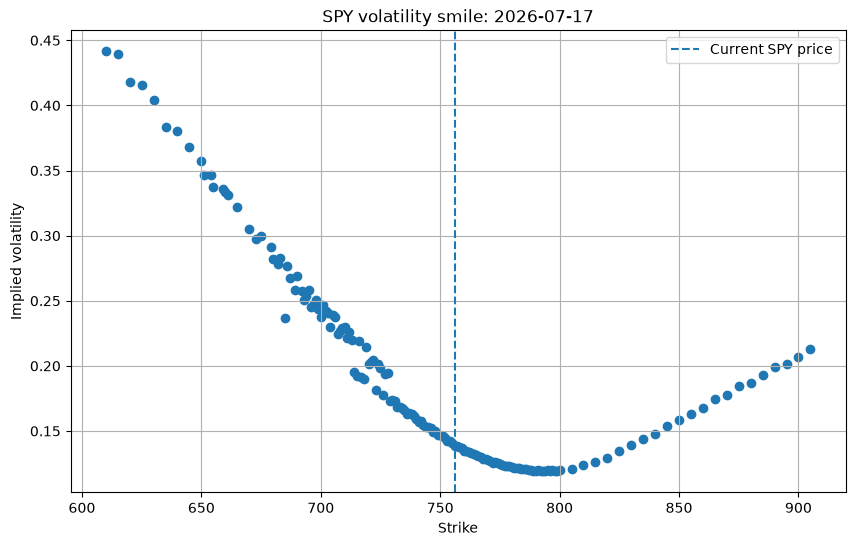

In [40]:
lower_strike = 0.8 * spot_price
upper_strike = 1.2 * spot_price

calls_near_money = calls[
    calls["strike"].between(
        lower_strike,
        upper_strike
    )
].copy()

plt.figure(figsize=(10, 6))

plt.scatter(
    calls_near_money["strike"],
    calls_near_money["impliedVolatility"]
)

plt.axvline(
    spot_price,
    linestyle="--",
    label="Current SPY price"
)

plt.xlabel("Strike")
plt.ylabel("Implied volatility")
plt.title(f"SPY volatility smile: {expiration}")
plt.legend()
plt.grid()

plt.show()

In [42]:
today = pd.Timestamp.now().normalize()
expiration_date = pd.Timestamp(expiration)

days_to_expiration = (expiration_date - today).days

T = days_to_expiration / 365

print("Days to expiration:", days_to_expiration)
print("Time to maturity:", T)

Days to expiration: 32
Time to maturity: 0.08767123287671233


In [43]:
forward_price = spot_price
calls_near_money["log_moneyness"] = np.log(calls_near_money["strike"] / forward_price)

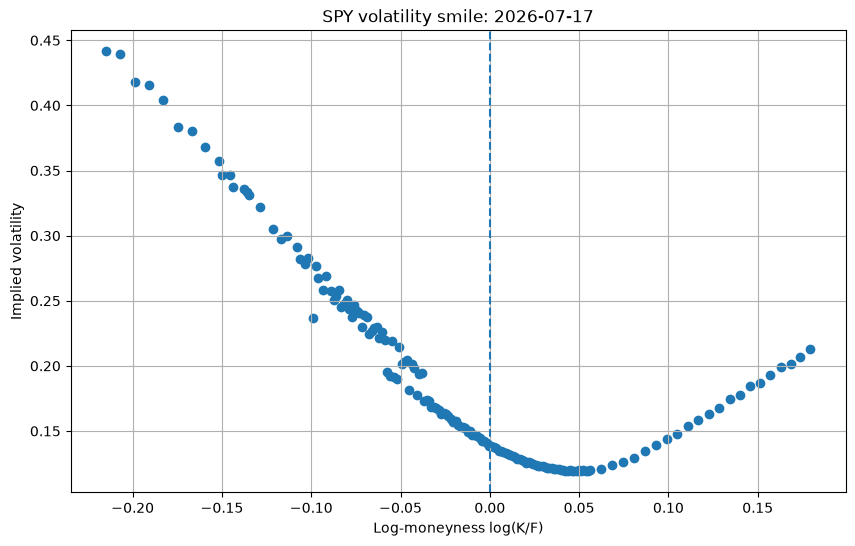

In [44]:
plt.figure(figsize=(10, 6))

plt.scatter(
    calls_near_money["log_moneyness"],
    calls_near_money["impliedVolatility"]
)
plt.axvline(0, linestyle="--")
plt.xlabel("Log-moneyness log(K/F)")
plt.ylabel("Implied volatility")
plt.title(f"SPY volatility smile: {expiration}")
plt.grid()
plt.show()

In [51]:
all_options = []

for expiration in expirations[:6]:

    chain = ticker.option_chain(expiration)
    calls = chain.calls.copy()

    calls = calls[
        (calls["bid"] > 0) &
        (calls["ask"] > calls["bid"])
    ].copy()

    calls["mid_price"] = (
        calls["bid"] + calls["ask"]
    ) / 2

    calls["relative_spread"] = (
        calls["ask"] - calls["bid"]
    ) / calls["mid_price"]

    calls = calls[
        calls["relative_spread"] < 0.30
    ].copy()

    expiration_date = pd.Timestamp(expiration)

    T = (
        expiration_date -
        pd.Timestamp.now().normalize()
    ).days / 365

    calls["T"] = T
    calls["expiration"] = expiration

    calls["log_moneyness"] = np.log(
        calls["strike"] / spot_price
    )

    all_options.append(calls)

In [53]:
options_data = pd.concat(
    all_options,
    ignore_index=True
)

(716, 19)

In [54]:
import plotly.graph_objects as go

figure = go.Figure(
    data=[
        go.Scatter3d(
            x=options_data["log_moneyness"],
            y=options_data["T"],
            z=options_data["impliedVolatility"],
            mode="markers"
        )
    ]
)

figure.update_layout(
    title="SPY implied-volatility data",
    scene={
        "xaxis_title": "Log-moneyness",
        "yaxis_title": "Time to maturity",
        "zaxis_title": "Implied volatility"
    }
)

figure.show()